# ArtBench-10

This notebook was firstly a template for class projects using **ArtBench-10**, provided by the teachers.

It already covered:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `../data/` (local folder with ArtBench-10 data)


In [1]:
from __future__ import annotations

import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

In [2]:
import torch
import torchvision
from torchvision import transforms as T

print(torchvision.__version__)
print(hasattr(T, "Resize"))

0.26.0+cu130
True


In [3]:
import torch

print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA disponível: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Relative paths (run this notebook from notebooks/)
PROJECT_ROOT = Path('..')
SCRIPTS_DIR = PROJECT_ROOT / 'src'
DATASET_ROOT = PROJECT_ROOT / 'data'

if not DATASET_ROOT.exists() or not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        'Could not resolve project folders from relative paths. '
        'Run this notebook from notebooks/ or adjust PROJECT_ROOT.'
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT   =', PROJECT_ROOT)
print('DATASET_ROOT   =', DATASET_ROOT)

PROJECT_ROOT   = ..
DATASET_ROOT   = ../data


In [5]:
# Load ArtBench-10 from local dataset folder
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(DATASET_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='../data'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']



Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


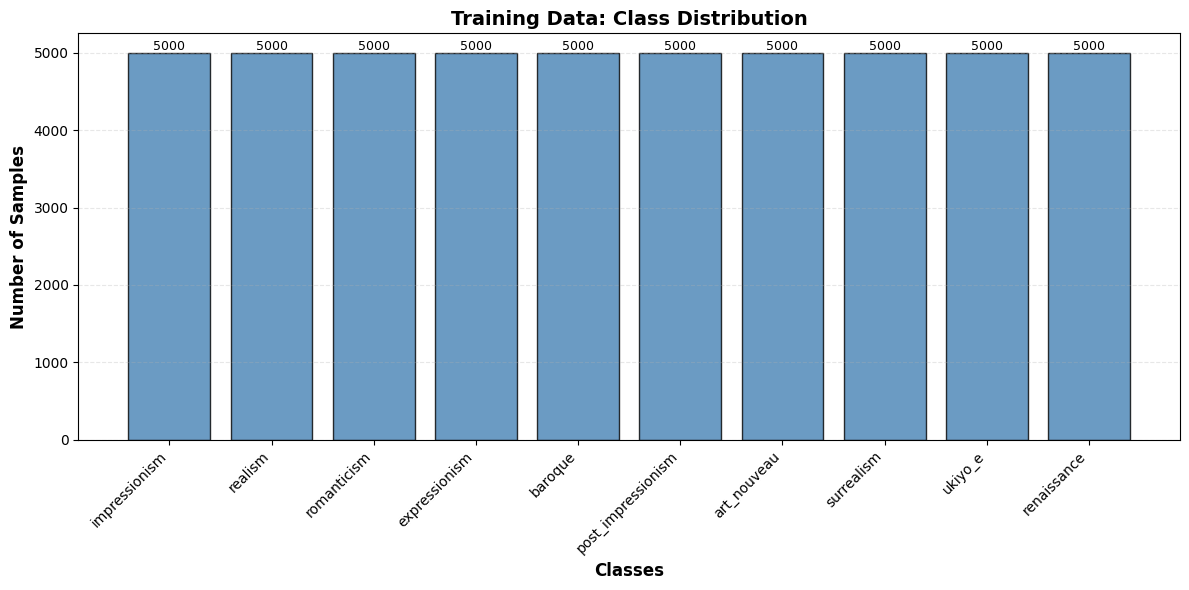

In [6]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")

# Visualize class distribution
fig, ax = plt.subplots(figsize=(12, 6))
counts = [train_counts.get(cid, 0) for cid in range(num_classes)]
bars = ax.bar(range(num_classes), counts, color='steelblue', alpha=0.8, edgecolor='black')

# Customize the plot
ax.set_xlabel('Classes', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Training Data: Class Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

**Important Note:** This creates `train_loader` which contains **100% of the training dataset**. 
This dataloader is used in **Phase 2** (final training). For quick development in **Phase 1**, use `train_loader_from_csv` (created in the next section) which contains only **20% of samples**.

In [7]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

# PHASE 2: Full training dataset (100% of train split)
# Use this dataloader for final model training after selecting the best architecture
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

**PHASE 1 DATALOADER**: This creates `train_loader_from_csv` which contains **exactly 20% of training samples**. Use this for rapid iteration on hyperparameters and model architecture selection. Training is ~3x faster than full dataset.

You can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.

In [8]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('../data/training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# PHASE 1: Fast development with 20% subset
# Use this dataloader to quickly iterate on hyperparameters and model selection
# Dataset is loaded from training_20_percent.csv which contains exactly 20% of training samples
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))

Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


## Visualize a sample grid

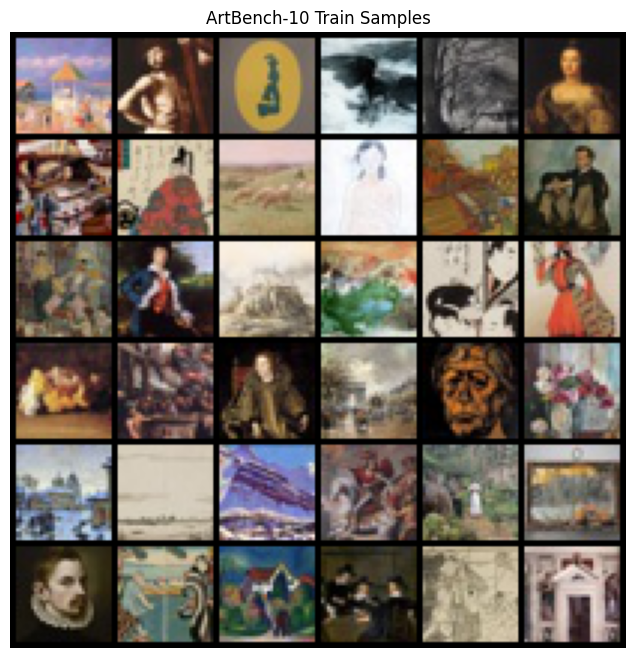

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [9]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [10]:
import csv

def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)


Exported 500 images to: exported_data/train_subset/images
Metadata CSV: exported_data/train_subset/metadata.csv


---

# 1. Implement and Train Generative Models

## Overview
This section implements four generative model families for comparison:
1. **VAE** (Variational Autoencoder) - Probabilistic autoencoder
2. **DCGAN** (Deep Convolutional GAN) - Adversarial network
3. **WGAN-GP** (Wasserstein GAN with Gradient Penalty) - Adversarial network
3. **Diffusion Model** - Denoising probabilistic model

**Development Strategy:**
- **Phase 1 (Development)**: Train and evaluate on 20% subset using `train_loader_from_csv`
- **Phase 2 (Production)**: Retrain best model on 100% dataset using `train_loader` with ≥10 random seeds
- **Metrics**: FID (quality/diversity) and KID (statistical robustness)

**Key Decision:** After Phase 1, we selected the best architecture based on FID score and training stability, then retrained in Phase 2 on full dataset.

In [11]:
# Additional imports for generative models and evaluation
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from scipy.linalg import sqrtm

# Device setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


---
## 1.1: VAE (Variational Autoencoder)
**What it does:**
- Encoder: Compresses 32×32 image → latent distribution (μ, σ)
- Reparameterization: Sample z ~ N(μ, σ)
- Decoder: Reconstructs image from z
- Loss: Reconstruction (MSE) + KL divergence

**Key advantages:** Stable training, interpretable latent space, good baseline

**Key trade-offs:** Potentially blurry images compared to GANs

In [12]:
class VAEEncoder(nn.Module):
    """VAE Encoder: 32×32 image → latent distribution (μ, log-var)"""
    def __init__(self, latent_dim=128, img_channels=3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(img_channels, 32, 4, stride=2, padding=1),   # 32→16
            nn.ReLU(), nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 16→8
            nn.ReLU(), nn.Conv2d(64, 128, 4, stride=2, padding=1), # 8→4
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)
    
    def forward(self, x):
        x = self.conv(x).view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)


class VAEDecoder(nn.Module):
    """VAE Decoder: latent sample → 32×32 image"""
    def __init__(self, latent_dim=128, img_channels=3):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 4→8
            nn.ReLU(), nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), # 8→16
            nn.ReLU(), nn.ConvTranspose2d(32, img_channels, 4, stride=2, padding=1), # 16→32
            nn.Sigmoid(),  # [0,1]
        )
    
    def forward(self, z):
        return self.deconv(self.fc(z).view(z.size(0), 128, 4, 4))


class VAE(nn.Module):
    """Variational Autoencoder"""
    def __init__(self, latent_dim=128, img_channels=3):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim, img_channels)
        self.decoder = VAEDecoder(latent_dim, img_channels)
        self.latent_dim = latent_dim
    
    def reparameterize(self, mu, logvar):
        """Sample z = μ + σ·ε"""
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)
        return z
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar
    
    def sample(self, num_samples):
        """Generate new samples"""
        z = torch.randn(num_samples, self.latent_dim, device=next(self.parameters()).device)
        return self.decoder(z)


def vae_loss(recon, x, mu, logvar, beta=1.0):
    """Loss = BCE(recon, x) + β·KL(q||p)"""
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

print("✓ VAE defined")

✓ VAE defined


---
## 1.2: DCGAN (Deep Convolutional GAN)
**What it does:**
- Generator: Noise → 32×32 realistic images  
- Discriminator: Image → probability "real or fake"
- Adversarial training: Generator fools discriminator, discriminator gets better
- Use batch normalization for stability

**Key advantages:** Sharp, high-quality images; well-studied architecture

**Key trade-offs:** Can have mode collapse; less diverse samples than VAE

In [13]:
class DCGANGenerator(nn.Module):
    """DCGAN Generator: noise → 32×32 images"""
    def __init__(self, latent_dim, img_channels):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, img_channels, 3, stride=1, padding=1, bias=False),
            nn.Sigmoid(),  # [0,1]
        )
    
    def forward(self, z):
        return self.main(self.fc(z).view(z.size(0), 256, 4, 4))


class DCGANDiscriminator(nn.Module):
    """DCGAN Discriminator: image → probability real"""
    def __init__(self, img_channels):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(img_channels, 32, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 1, 4, stride=1, padding=0, bias=False),
        )
    
    def forward(self, x):
        return self.main(x).view(x.size(0), -1)

print("✓ DCGAN defined")

✓ DCGAN defined


---
## 1.3: WGAN-GP (Wasserstein GAN with Gradient Penalty)
**What it does:**
- Generator: Noise → 32×32 realistic images
- Critic (Discriminator): Image → unbounded real-valued score (not probability)
- Wasserstein loss: Simpler training objective than BCE
- Gradient Penalty: Enforces 1-Lipschitz constraint on critic

**Key advantages:** More stable training than vanilla GAN; prevents mode collapse better

**Key trade-offs:** Requires gradient penalty computation; slower training than DCGAN

In [21]:
class WGANGPGenerator(nn.Module):
    """WGAN-GP Generator: noise → 32×32 images (outputs unbounded values)"""
    def __init__(self, latent_dim, img_channels):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, img_channels, 3, stride=1, padding=1, bias=False),
            # No Sigmoid - output is unbounded for Wasserstein loss
        )
    
    def forward(self, z):
        return self.main(self.fc(z).view(z.size(0), 256, 4, 4))


class WGANGPCritic(nn.Module):
    def __init__(self, img_channels):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(img_channels, 32, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 1, 4, stride=1, padding=0, bias=False),
        )
    
    def forward(self, x):
        return self.main(x).view(x.size(0), -1)


def gradient_penalty(critic, real_images, fake_images, device, lambda_gp=10):
    """Compute gradient penalty for WGAN-GP
    
    Args:
        critic: Critic network
        real_images: Real image batch (B, C, H, W)
        fake_images: Generated image batch (B, C, H, W)
        device: Device (cuda/cpu)
        lambda_gp: Gradient penalty weight
    
    Returns:
        Gradient penalty loss
    """
    batch_size = real_images.size(0)
    
    # Random interpolation between real and fake
    alpha = torch.rand(batch_size, 1, 1, 1, device=device, requires_grad=True)
    interpolates = (alpha * real_images + (1 - alpha) * fake_images).requires_grad_(True)
    
    critic_score = critic(interpolates)
    
    # Compute gradient
    gradients = torch.autograd.grad(
        outputs=critic_score,
        inputs=interpolates,
        grad_outputs=torch.ones_like(critic_score),
        create_graph=True,
        retain_graph=True,
    )[0]
    
    # Compute gradient penalty
    gradients_flat = gradients.view(batch_size, -1)
    grad_norm = torch.sqrt(torch.sum(gradients_flat ** 2, dim=1) + 1e-12)
    grad_penalty = lambda_gp * torch.mean((grad_norm - 1) ** 2)
    
    return grad_penalty

print("✓ WGAN-GP defined")

✓ WGAN-GP defined


---
## 1.4: Diffusion Model
**What it does:**
- Forward process: Gradually add Gaussian noise to image over T steps
- Backward process: Train UNet to predict and remove noise step-by-step
- Sampling: Start from pure noise, iteratively denoise → clean image
- Loss: MSE between predicted and actual noise

**Key advantages:** State-of-the-art quality; stable, interpretable training

**Key trade-offs:** Slow sampling (requires ~1000 steps vs GANs' single pass)

In [15]:
class DiffusionSchedule:
    """Linear noise schedule for diffusion process"""
    def __init__(self, num_steps=1000, beta_start=0.0001, beta_end=0.02):
        self.num_steps = num_steps
        self.betas = torch.linspace(beta_start, beta_end, num_steps)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
    
    def to(self, device):
        for attr in ['betas', 'alphas', 'alphas_cumprod', 'sqrt_alphas_cumprod', 'sqrt_one_minus_alphas_cumprod']:
            setattr(self, attr, getattr(self, attr).to(device))
        return self
    
    def add_noise(self, x0, t, noise):
        """x_t = √(ᾱ_t) x_0 + √(1-ᾱ_t) ε"""
        alpha_t = self.sqrt_alphas_cumprod[t]
        sigma_t = self.sqrt_one_minus_alphas_cumprod[t]
        while len(alpha_t.shape) < len(x0.shape):
            alpha_t = alpha_t.unsqueeze(-1)
            sigma_t = sigma_t.unsqueeze(-1)
        return alpha_t * x0 + sigma_t * noise


class SimpleUNet(nn.Module):
    """UNet for noise prediction in diffusion model"""
    def __init__(self, img_channels=3, time_dim=32):
        super().__init__()
        self.time_embed = nn.Sequential(nn.Linear(1, time_dim), nn.SiLU(), nn.Linear(time_dim, time_dim))
        # Simplified UNet: encoder -> bottleneck -> decoder
        self.enc1 = nn.Sequential(nn.Conv2d(img_channels, 32, 3, padding=1), nn.SiLU())
        self.enc2 = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(32, 64, 3, padding=1), nn.SiLU())
        self.enc3 = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(64, 128, 3, padding=1), nn.SiLU())
        self.bottleneck = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(128, 256, 3, padding=1), nn.SiLU(), 
                                       nn.Upsample(scale_factor=2), nn.Conv2d(256, 128, 3, padding=1), nn.SiLU())
        self.dec3 = nn.Sequential(nn.Upsample(scale_factor=2), nn.Conv2d(256, 64, 3, padding=1), nn.SiLU())
        self.dec2 = nn.Sequential(nn.Upsample(scale_factor=2), nn.Conv2d(128, 32, 3, padding=1), nn.SiLU())
        self.out = nn.Conv2d(32, img_channels, 3, padding=1)
    
    def forward(self, x, t):
        t_emb = self.time_embed(t.float().unsqueeze(-1) / 1000)
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        b = self.bottleneck(e3)
        d3 = self.dec3(torch.cat([b, e3], dim=1))
        d2 = self.dec2(torch.cat([d3, e2], dim=1))
        return self.out(torch.cat([d2, e1], dim=1))

print("✓ Diffusion model defined")

✓ Diffusion model defined


---
## 1.5: Training Functions

**Training procedures for each model:**
- **VAE**: Optimize encoder + decoder with reconstruction + KL loss
- **DCGAN**: Alternate training of discriminator (classifies) and generator (fools)
- **WGAN-GP**: Critic maximizes Wasserstein distance; generator minimizes it; gradient penalty enforces Lipschitz constraint
- **Diffusion**: Predict noise at random timesteps with MSE loss

In [22]:
def train_vae(model, train_loader, num_epochs, learning_rate, beta):
    """Train VAE on dataloader
    
    Args:
        train_loader: Use train_loader_from_csv for Phase 1 (20% subset, fast iteration)
                      Use train_loader for Phase 2 (100% dataset, final results)
    """
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    history = {'total_loss': [], 'recon_loss': [], 'kl_loss': []}
    
    for epoch in range(num_epochs):
        total_sum, recon_sum, kl_sum = 0, 0, 0
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            recon, mu, logvar = model(x)
            total_loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, beta=beta)
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            total_sum += total_loss.item()
            recon_sum += recon_loss.item()
            kl_sum += kl_loss.item()
        
        history['total_loss'].append(total_sum / len(train_loader))
        history['recon_loss'].append(recon_sum / len(train_loader))
        history['kl_loss'].append(kl_sum / len(train_loader))
        if (epoch + 1) % 10 == 0:
            print(f"VAE Epoch {epoch+1}: Total={history['total_loss'][-1]:.4f}")
    return model, history


def train_dcgan(gen, disc, train_loader, num_epochs, learning_rate, latent_dim):
    """Train DCGAN on dataloader
    
    Args:
        train_loader: Use train_loader_from_csv for Phase 1 (20% subset, fast iteration)
                      Use train_loader for Phase 2 (100% dataset, final results)
    """
    gen, disc = gen.to(DEVICE), disc.to(DEVICE)

    # Set up optimizers for generator and discriminator
    opt_g = optim.Adam(gen.parameters(), lr=learning_rate, betas=(0.5, 0.999))
    opt_d = optim.Adam(disc.parameters(), lr=learning_rate, betas=(0.5, 0.999))

    # Define loss function (BCEWithLogitsLoss combines sigmoid + binary cross-entropy)
    criterion = nn.BCEWithLogitsLoss()
    history = {'g_loss': [], 'd_loss': []}
    
    for epoch in range(num_epochs):
        g_sum, d_sum = 0, 0
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            bs = x.size(0)
            
            # Train Discriminator
            opt_d.zero_grad()
            real_out = disc(x)  # sees real images (should output 1)

            # Label smoothing: real=0.9, fake=0.1
            d_real = criterion(real_out, torch.ones(bs, 1, device=DEVICE) * 0.9)

            z = torch.randn(bs, latent_dim, device=DEVICE)
            fake = gen(z)  # sees fake images (should output 0)
            d_fake = criterion(disc(fake.detach()), torch.zeros(bs, 1, device=DEVICE) + 0.1) # detach to avoid backprop to generator
            d_loss = d_real + d_fake # total discriminator loss
            d_loss.backward()
            opt_d.step()
            
            # Train Generator
            opt_g.zero_grad()
            z = torch.randn(bs, latent_dim, device=DEVICE)
            fake = gen(z)
            g_loss = criterion(disc(fake), torch.ones(bs, 1, device=DEVICE)) # the target is 1 (so disc thinks generated images are real)
            g_loss.backward()
            opt_g.step()
            
            g_sum += g_loss.item()
            d_sum += d_loss.item()
        
        history['g_loss'].append(g_sum / len(train_loader))
        history['d_loss'].append(d_sum / len(train_loader))
        if (epoch + 1) % 10 == 0:
            print(f"DCGAN Epoch {epoch+1}: G={history['g_loss'][-1]:.4f}, D={history['d_loss'][-1]:.4f}")
    return gen, disc, history


def train_wgan_gp(gen, critic, train_loader, num_epochs, learning_rate, latent_dim, lambda_gp=10, n_critic=5):
    """Train WGAN-GP on dataloader
    
    Args:
        train_loader: Use train_loader_from_csv for Phase 1 (20% subset, fast iteration)
                      Use train_loader for Phase 2 (100% dataset, final results)
        lambda_gp: Gradient penalty weight
        n_critic: Number of critic updates per generator update
    """
    gen, critic = gen.to(DEVICE), critic.to(DEVICE)
    opt_g = optim.Adam(gen.parameters(), lr=learning_rate, betas=(0.5, 0.999))
    opt_c = optim.Adam(critic.parameters(), lr=learning_rate, betas=(0.5, 0.999))
    history = {'g_loss': [], 'c_loss': []}
    
    for epoch in range(num_epochs):
        g_sum, c_sum = 0, 0
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            bs = x.size(0)
            
            # Train Critic (multiple steps)
            for _ in range(n_critic):
                opt_c.zero_grad()
                z = torch.randn(bs, latent_dim, device=DEVICE)
                fake = gen(z).detach()
                
                # Wasserstein loss
                real_score = critic(x)
                fake_score = critic(fake)
                c_loss = -torch.mean(real_score) + torch.mean(fake_score)
                
                # Gradient penalty
                gp = gradient_penalty(critic, x, fake, DEVICE, lambda_gp)
                total_c_loss = c_loss + gp
                total_c_loss.backward()
                opt_c.step()
                c_sum += total_c_loss.item()
            
            # Train Generator
            opt_g.zero_grad()
            z = torch.randn(bs, latent_dim, device=DEVICE)
            fake = gen(z)
            g_loss = -torch.mean(critic(fake))
            g_loss.backward()
            opt_g.step()
            g_sum += g_loss.item()
        
        history['g_loss'].append(g_sum / len(train_loader))
        history['c_loss'].append(c_sum / (len(train_loader) * n_critic))
        if (epoch + 1) % 10 == 0:
            print(f"WGAN-GP Epoch {epoch+1}: G={history['g_loss'][-1]:.4f}, C={history['c_loss'][-1]:.4f}")
    return gen, critic, history


def train_diffusion(model, train_loader, num_epochs, learning_rate, num_steps):
    """Train Diffusion model on dataloader
    
    Args:
        train_loader: Use train_loader_from_csv for Phase 1 (20% subset, fast iteration)
                      Use train_loader for Phase 2 (100% dataset, final results)
    """
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    schedule = DiffusionSchedule(num_steps=num_steps).to(DEVICE)
    history = {'loss': []}
    
    for epoch in range(num_epochs):
        loss_sum = 0
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            t = torch.randint(0, num_steps, (x.size(0),), device=DEVICE)
            noise = torch.randn_like(x)
            x_t = schedule.add_noise(x, t, noise)
            noise_pred = model(x_t, t)
            loss = nn.functional.mse_loss(noise_pred, noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
        
        history['loss'].append(loss_sum / len(train_loader))
        if (epoch + 1) % 10 == 0:
            print(f"Diffusion Epoch {epoch+1}: Loss={history['loss'][-1]:.4f}")
    return model, history

print("✓ Training functions defined")

✓ Training functions defined


## 3.5: Evaluation Metrics (FID & KID)

**Evaluating generative model quality requires comparing generated samples to real data:**

- **FID (Fréchet Inception Distance)**: 
  - Extracts features from pre-trained Inception-v3 network
  - Computes Fréchet distance between real and generated feature distributions
  - Lower = better quality and diversity
  - Requires: ~5000 real samples, ~5000 generated samples for stable estimate

- **KID (Kernel Inception Distance)**:
  - Uses quadratic Kernel Maximum Mean Discrepancy (MMD) between features
  - Reports mean ± std across 50 random subsets (100 samples each)
  - More stable than FID with fewer samples
  - Formula: KID = ||E_r[φ(r)] - E_g[φ(g)]||²_k

**Implementation approach:**
1. Extract features from Inception-v3 layer before classification
2. For FID: compute Fréchet distance via covariance matrices
3. For KID: apply RBF kernel and quadratic MMD distance
4. Support batch processing to handle memory constraints

In [17]:
from torchvision import models
from torchvision.models.feature_extraction import create_feature_extractor
from scipy.linalg import sqrtm
from sklearn.metrics.pairwise import rbf_kernel
import warnings
warnings.filterwarnings('ignore')

class InceptionFeatureExtractor:
    """Extract features from pre-trained Inception-v3"""
    def __init__(self, device='cpu'):
        # Load pre-trained Inception-v3
        # aux_logits must be True for the pre-trained weights
        inception = models.inception_v3(weights='DEFAULT', aux_logits=True)
        
        # Extract features from the last average pooling layer
        # This gives us features before the classification head
        self.feature_extractor = create_feature_extractor(
            inception, 
            return_nodes={'avgpool': 'features'}
        )
        
        self.device = device
        self.feature_extractor = self.feature_extractor.to(device)
        self.feature_extractor.eval()
        
        for param in self.feature_extractor.parameters():
            param.requires_grad = False
    
    def extract(self, images):
        """Extract features for batch of images
        
        Args:
            images: Tensor of shape (batch, 3, H, W) with values in [0, 1]
        
        Returns:
            Feature tensor of shape (batch, feature_dim)
        """
        with torch.no_grad():
            # Ensure images are on the correct device and have correct dtype
            images = images.to(self.device).float()
            
            # Resize to 299x299 (required by Inception-v3)
            images_resized = nn.functional.interpolate(
                images, size=(299, 299), mode='bilinear', align_corners=False
            )
            
            # Normalize using ImageNet statistics
            mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(self.device)
            std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(self.device)
            images_normalized = (images_resized - mean) / std
            
            # Extract features
            feature_dict = self.feature_extractor(images_normalized)
            features = feature_dict['features']  # Shape: (batch, 2048, 1, 1)
            
            # Flatten to (batch, feature_dim)
            return features.view(features.size(0), -1)


def extract_features_from_tensor(samples_tensor, feature_extractor, device, batch_size=128):
    """Extract Inception features from tensor samples (not from dataloader)
    
    Args:
        samples_tensor: Tensor of shape (N, 3, 32, 32) with values in [0, 1]
        feature_extractor: InceptionFeatureExtractor instance
        device: Device to use for computation
        batch_size: Batch size for processing
        
    Returns:
        Numpy array of shape (N, feature_dim) with extracted features
    """
    all_features = []
    
    with torch.no_grad():
        for i in range(0, len(samples_tensor), batch_size):
            batch = samples_tensor[i:i+batch_size].to(device)
            features = feature_extractor.extract(batch)
            all_features.append(features.cpu().numpy())
    
    return np.concatenate(all_features, axis=0)


def calculate_fid(real_features, generated_features):
    """Calculate Fréchet Inception Distance
    
    Computes FID between real and generated feature distributions.
    Lower values indicate better quality and diversity.
    
    Args:
        real_features: Features from real images, shape (N, feature_dim)
        generated_features: Features from generated images, shape (M, feature_dim)
    
    Returns:
        FID score (lower is better)
    """
    mu_real = real_features.mean(axis=0)
    mu_gen = generated_features.mean(axis=0)
    sigma_real = np.cov(real_features.T)
    sigma_gen = np.cov(generated_features.T)
    
    diff = mu_real - mu_gen
    m = np.dot(diff, diff)
    s = sqrtm(np.dot(sigma_real, sigma_gen)).real
    
    return m + np.trace(sigma_real + sigma_gen - 2*s)


def calculate_kid(real_features, generated_features, n_subsets=50, subset_size=100):
    """Calculate Kernel Inception Distance with random subsets
    
    Args:
        real_features: Features from real images, shape (N, feature_dim)
        generated_features: Features from generated images, shape (M, feature_dim)
        n_subsets: Number of random subsets to evaluate
        subset_size: Size of each subset
    
    Returns:
        KID mean and std across subsets
    """
    n_real = len(real_features)
    n_gen = len(generated_features)
    
    kid_values = []
    for _ in range(n_subsets):
        # Sample random indices
        real_idx = np.random.choice(n_real, subset_size, replace=False)
        gen_idx = np.random.choice(n_gen, subset_size, replace=False)
        
        real_subset = real_features[real_idx]
        gen_subset = generated_features[gen_idx]
        
        # Compute kernel Inception Distance using RBF kernel
        K_rr = rbf_kernel(real_subset)
        K_gg = rbf_kernel(gen_subset)
        K_rg = rbf_kernel(real_subset, gen_subset)
        
        kid = np.mean(K_rr) + np.mean(K_gg) - 2 * np.mean(K_rg)
        kid_values.append(max(0, kid))  # KID should be non-negative
    
    return np.mean(kid_values), np.std(kid_values)

print("✓ Evaluation functions defined with GPU support")

✓ Evaluation functions defined with GPU support


## 3.6: Sample Generation

**Generating new samples from trained models:**

- **VAE**: Sample from standard normal distribution, pass through decoder
- **DCGAN**: Sample latent vectors, pass through generator
- **Diffusion**: Start from pure noise, iteratively denoise over T steps

**Workflow:**
1. Set model to eval mode
2. Disable gradients with `torch.no_grad()`
3. Generate in batches to manage memory
4. Denormalize images back to [0, 1] range
5. Return as tensor for evaluation or visualization

In [23]:
def generate_vae_samples(model, num_samples=5000, latent_dim=64, batch_size=128):
    """Generate samples from trained VAE"""
    model.eval()
    samples = []
    with torch.no_grad():
        for _ in range(0, num_samples, batch_size):
            batch_size_actual = min(batch_size, num_samples - len(samples))
            z = torch.randn(batch_size_actual, latent_dim, device=DEVICE)
            sample = model.decoder(z)
            samples.append(sample.cpu())
    return torch.cat(samples, dim=0)[:num_samples]


def generate_dcgan_samples(generator, num_samples=5000, latent_dim=128, batch_size=128):
    """Generate samples from trained DCGAN"""
    generator.eval()
    samples = []
    with torch.no_grad():
        for _ in range(0, num_samples, batch_size):
            batch_size_actual = min(batch_size, num_samples - len(samples))
            z = torch.randn(batch_size_actual, latent_dim, device=DEVICE)
            sample = generator(z)
            samples.append(sample.cpu())
    return torch.clamp(torch.cat(samples, dim=0)[:num_samples], 0, 1)


def generate_wgan_gp_samples(generator, num_samples=5000, latent_dim=128, batch_size=128):
    """Generate samples from trained WGAN-GP generator"""
    generator.eval()
    samples = []
    with torch.no_grad():
        for _ in range(0, num_samples, batch_size):
            batch_size_actual = min(batch_size, num_samples - len(samples))
            z = torch.randn(batch_size_actual, latent_dim, device=DEVICE)
            sample = generator(z)
            samples.append(sample.cpu())
    # WGAN-GP outputs unbounded values, so clamp to [0, 1]
    return torch.clamp(torch.cat(samples, dim=0)[:num_samples], 0, 1)


def generate_diffusion_samples(model, schedule, num_samples=5000, batch_size=128):
    """Generate samples from trained Diffusion model (reverse process)"""
    model.eval()
    samples = []
    with torch.no_grad():
        for _ in range(0, num_samples, batch_size):
            batch_size_actual = min(batch_size, num_samples - len(samples))
            x = torch.randn(batch_size_actual, 3, 32, 32, device=DEVICE)
            
            for t in range(schedule.num_steps-1, -1, -1):
                t_tensor = torch.full((batch_size_actual,), t, device=DEVICE, dtype=torch.long)
                noise_pred = model(x, t_tensor)
                x = schedule.reverse_step(x, t, noise_pred)
            
            samples.append(torch.clamp(x.cpu(), 0, 1))
    return torch.cat(samples, dim=0)[:num_samples]


def get_real_samples(data_loader, num_samples=5000):
    """Collect real samples from dataloader"""
    real_samples = []
    with torch.no_grad():
        for x, _, _ in data_loader:
            real_samples.append(x)
            if sum(s.size(0) for s in real_samples) >= num_samples:
                break
    samples = torch.cat(real_samples, dim=0)[:num_samples]
    return samples.to(DEVICE)

print("✓ Sample generation functions defined")

✓ Sample generation functions defined


## 3.7: Utility Functions

In [24]:
def set_seed(seed=42):
    """Set random seed for reproducibility"""
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)


def create_results_dataframe(results_dict):
    """Create pandas DataFrame from results across seeds"""
    data = []
    for seed, metrics in results_dict.items():
        row = {'Seed': seed}
        row.update(metrics)
        data.append(row)
    return pd.DataFrame(data)


def plot_training_history(history_dict, model_name='Model'):
    fig, axes = plt.subplots(1, len(history_dict), figsize=(5*len(history_dict), 4))
    if len(history_dict) == 1:
        axes = [axes]
    
    for (key, losses), ax in zip(history_dict.items(), axes):
        ax.plot(losses, linewidth=2)
        ax.set_title(f'{model_name} - {key}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def show_generated_samples(samples, n_images=36, nrow=6, title='Generated Samples'):
    grid = make_grid(samples[:n_images], nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()
    
    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

# AINDA NAO USADA
def save_checkpoint(model, optimizer, epoch, loss, path):      
    """Save model checkpoint"""
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'loss': loss
    }, path)

# AINDA NAO USADA
def load_checkpoint(model, optimizer, path):
    """Load model checkpoint"""
    checkpoint = torch.load(path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    return model, optimizer, checkpoint['epoch'], checkpoint['loss']

print("✓ Utility functions defined")

✓ Utility functions defined


---

# STEP 4: Full Training & Evaluation Workflow

## Phase 1: Rapid Development on 20% Subset

**Dataloader to use:** `train_loader_from_csv` (loaded from `training_20_percent.csv` contains exactly 20% of samples)



Common variables for all models:
- EPOCHS = 70
- LATENT_DIM = 128
- BATCH_SIZE = 128
- LEARNING_RATE = 0.0002
- IMAGE_SIZE = 32
- SEED = 42

Era fixe manter as variaveis em comum nos modelos iguais, para poder compará-los cm deve ser.

### Setup for Phase 1 Evaluation
Initialize evaluation infrastructure once before training the models.

In [25]:
# Initialize Inception feature extractor once for all Phase 1 evaluations
feature_extractor_phase1 = InceptionFeatureExtractor(device=DEVICE)

# Collect 5000 real samples once from the 20% subset
print("[Phase 1 Setup] Collecting 5000 real samples from training subset...")
real_samples_phase1 = get_real_samples(train_loader_from_csv, num_samples=5000)
print(f"[Phase 1 Setup] Real samples shape: {real_samples_phase1.shape}")

# Extract Inception features from real samples
print("[Phase 1 Setup] Extracting Inception features from real samples...")
real_features_phase1 = extract_features_from_tensor(real_samples_phase1, feature_extractor_phase1, DEVICE, batch_size=128)
print(f"[Phase 1 Setup] Real features shape: {real_features_phase1.shape}")
print("[Phase 1 Setup] ✓ Ready to evaluate models\n")

phase1_results = {}

[Phase 1 Setup] Collecting 5000 real samples from training subset...
[Phase 1 Setup] Real samples shape: torch.Size([5000, 3, 32, 32])
[Phase 1 Setup] Extracting Inception features from real samples...
[Phase 1 Setup] Real features shape: (5000, 2048)
[Phase 1 Setup] ✓ Ready to evaluate models



VAE Model

Training VAE on 20% subset...
VAE Epoch 10: Total=0.6414
VAE Epoch 20: Total=0.6392
VAE Epoch 30: Total=0.6389
VAE Epoch 40: Total=0.6388
VAE Epoch 50: Total=0.6386
VAE Epoch 60: Total=0.6385
VAE Epoch 70: Total=0.6383

Generating 5000 VAE samples...
Extracting Inception features from VAE samples...
Computing FID...
Computing KID (50 subsets of 100 samples)...

✓ VAE Metrics - FID: 364.1924 | KID: 0.173474 ± 0.004695



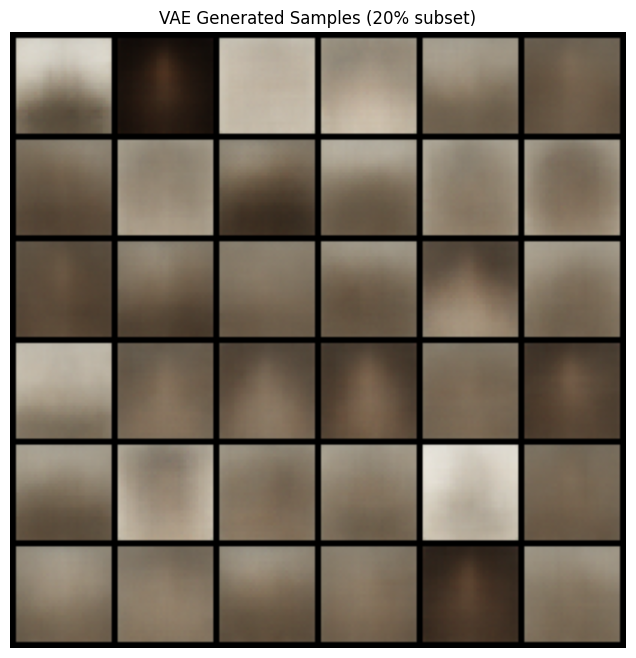

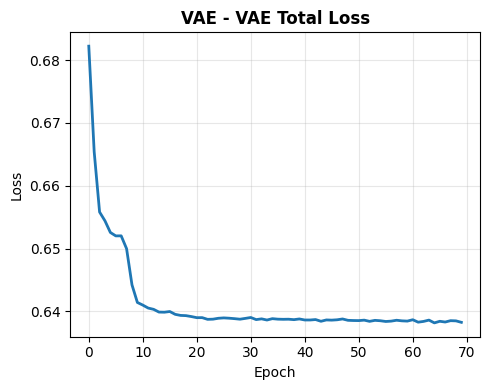

In [50]:
set_seed(SEED)

# Initialize and train VAE model
vae = VAE(latent_dim=128)
print("Training VAE on 20% subset...")
vae_trained, vae_history = train_vae(vae, train_loader_from_csv, num_epochs=70, learning_rate=0.0002, beta=1.0)

# Generate 5000 samples for evaluation
print("\nGenerating 5000 VAE samples...")
samples_vae = generate_vae_samples(vae_trained, num_samples=5000, latent_dim=128, batch_size=128)

# Extract features and compute metrics
print("Extracting Inception features from VAE samples...")
vae_gen_features = extract_features_from_tensor(samples_vae, feature_extractor_phase1, DEVICE, batch_size=128)

print("Computing FID...")
vae_fid = calculate_fid(real_features_phase1, vae_gen_features)

print("Computing KID (50 subsets of 100 samples)...")
vae_kid_mean, vae_kid_std = calculate_kid(real_features_phase1, vae_gen_features, n_subsets=50, subset_size=100)

phase1_results['VAE'] = {'FID': vae_fid, 'KID_mean': vae_kid_mean, 'KID_std': vae_kid_std}
print(f"\n✓ VAE Metrics - FID: {vae_fid:.4f} | KID: {vae_kid_mean:.6f} ± {vae_kid_std:.6f}\n")

# Visualize generated samples and training history
show_generated_samples(samples_vae, title='VAE Generated Samples (20% subset)')
plot_training_history({'VAE Total Loss': vae_history['total_loss']}, model_name='VAE')


DCGAN Model

Training DCGAN on 20% subset...
DCGAN Epoch 10: G=0.7906, D=1.3760
DCGAN Epoch 20: G=0.8047, D=1.3528
DCGAN Epoch 30: G=0.8565, D=1.3277
DCGAN Epoch 40: G=1.0049, D=1.2450
DCGAN Epoch 50: G=1.2371, D=1.1067
DCGAN Epoch 60: G=1.4427, D=1.0167
DCGAN Epoch 70: G=1.4616, D=0.9366

Generating 5000 DCGAN samples...
Extracting Inception features from DCGAN samples...
Computing FID...
Computing KID (50 subsets of 100 samples)...

✓ DCGAN Metrics - FID: 79.2271 | KID: 0.030398 ± 0.003485



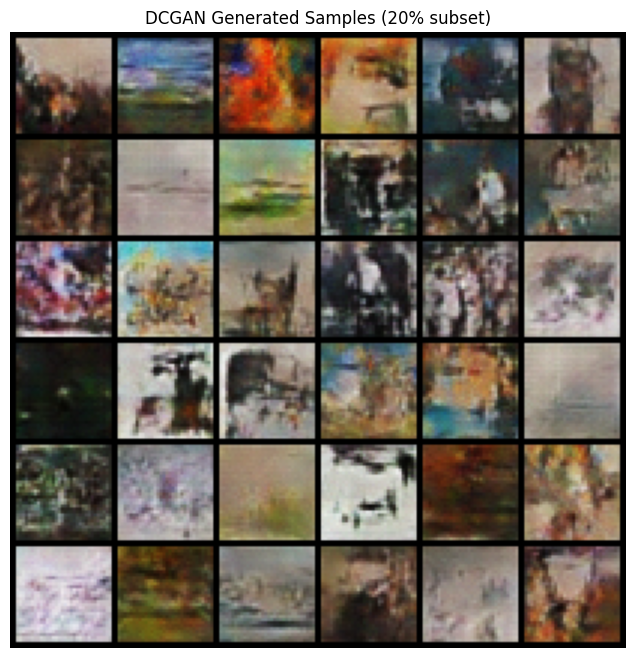

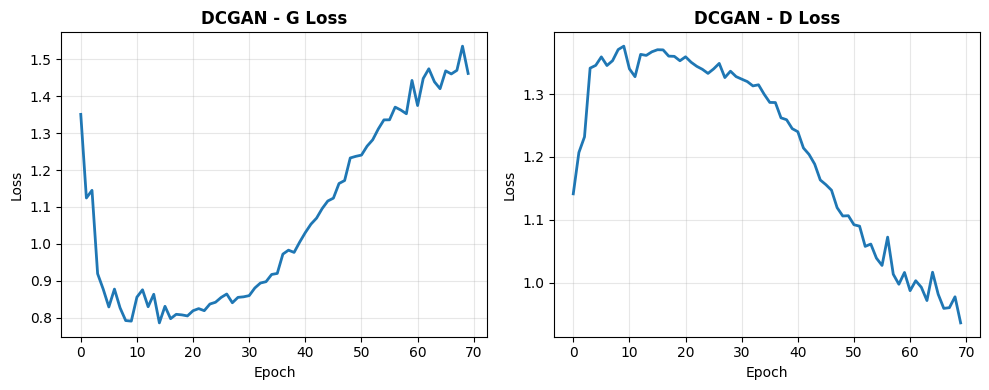

In [51]:
set_seed(SEED)

# Initialize and train DCGAN models
dcgan_gen = DCGANGenerator(latent_dim=128, img_channels=3)
dcgan_disc = DCGANDiscriminator(img_channels=3)
print("Training DCGAN on 20% subset...")
dcgan_gen, dcgan_disc, dcgan_hist = train_dcgan(dcgan_gen, dcgan_disc, train_loader_from_csv, num_epochs=70, learning_rate=0.0002, latent_dim=128)

# Generate 5000 samples for evaluation
print("\nGenerating 5000 DCGAN samples...")
sample_dcgan = generate_dcgan_samples(dcgan_gen, num_samples=5000, latent_dim=128, batch_size=128)

# Extract features and compute metrics
print("Extracting Inception features from DCGAN samples...")
dcgan_gen_features = extract_features_from_tensor(sample_dcgan, feature_extractor_phase1, DEVICE, batch_size=128)

print("Computing FID...")
dcgan_fid = calculate_fid(real_features_phase1, dcgan_gen_features)

print("Computing KID (50 subsets of 100 samples)...")
dcgan_kid_mean, dcgan_kid_std = calculate_kid(real_features_phase1, dcgan_gen_features, n_subsets=50, subset_size=100)

phase1_results['DCGAN'] = {'FID': dcgan_fid, 'KID_mean': dcgan_kid_mean, 'KID_std': dcgan_kid_std}
print(f"\n✓ DCGAN Metrics - FID: {dcgan_fid:.4f} | KID: {dcgan_kid_mean:.6f} ± {dcgan_kid_std:.6f}\n")

# Visualize generated samples and training history
show_generated_samples(sample_dcgan, title='DCGAN Generated Samples (20% subset)')
plot_training_history({
    'G Loss': dcgan_hist['g_loss'],
    'D Loss': dcgan_hist['d_loss']
}, model_name='DCGAN')

WGAN-GP Model

Training WGAN-GP on 20% subset...
WGAN-GP Epoch 10: G=1.2111, C=-1.3365
WGAN-GP Epoch 20: G=0.9484, C=-0.8908
WGAN-GP Epoch 30: G=1.4046, C=-0.7858
WGAN-GP Epoch 40: G=0.6860, C=-0.6026
WGAN-GP Epoch 50: G=0.8595, C=-0.6631
WGAN-GP Epoch 60: G=0.7172, C=-0.6341
WGAN-GP Epoch 70: G=0.5024, C=-0.6048

Generating 5000 WGAN-GP samples...
Extracting Inception features from WGAN-GP samples...
Computing FID...
Computing KID (50 subsets of 100 samples)...

✓ WGAN-GP Metrics - FID: 251.8799 | KID: 0.111537 ± 0.005097



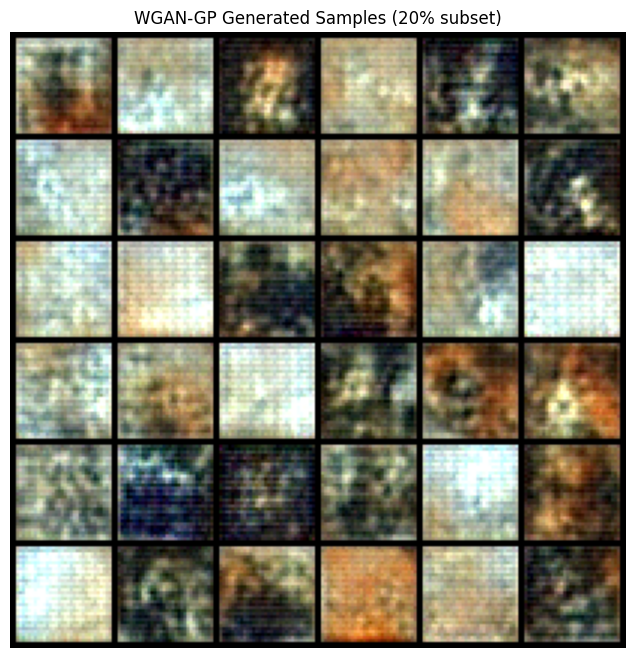

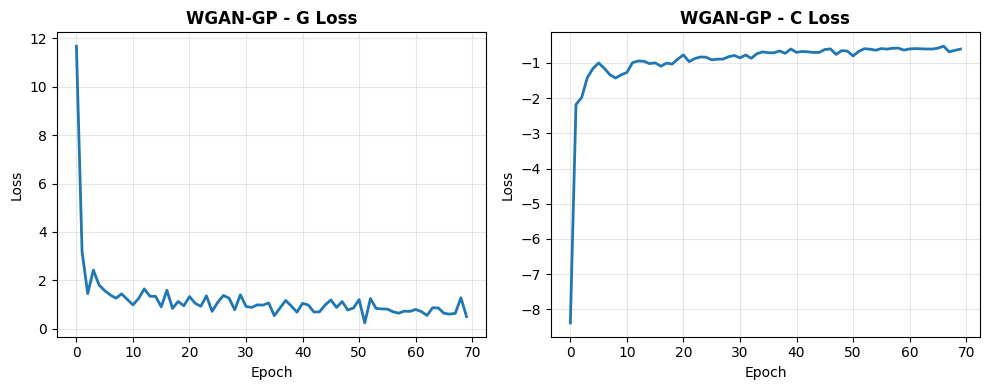

In [26]:
set_seed(SEED)

# Initialize and train WGAN-GP models
wgan_gp_gen = WGANGPGenerator(latent_dim=128, img_channels=3)
wgan_gp_critic = WGANGPCritic(img_channels=3)
print("Training WGAN-GP on 20% subset...")
wgan_gp_gen, wgan_gp_critic, wgan_gp_hist = train_wgan_gp(wgan_gp_gen, wgan_gp_critic, train_loader_from_csv, num_epochs=70, learning_rate=1e-4, latent_dim=128, lambda_gp=10, n_critic=5)

# Generate 5000 samples for evaluation
print("\nGenerating 5000 WGAN-GP samples...")
sample_wgan_gp = generate_wgan_gp_samples(wgan_gp_gen, num_samples=5000, latent_dim=128, batch_size=128)

# Extract features and compute metrics
print("Extracting Inception features from WGAN-GP samples...")
wgan_gp_gen_features = extract_features_from_tensor(sample_wgan_gp, feature_extractor_phase1, DEVICE, batch_size=128)

print("Computing FID...")
wgan_gp_fid = calculate_fid(real_features_phase1, wgan_gp_gen_features)

print("Computing KID (50 subsets of 100 samples)...")
wgan_gp_kid_mean, wgan_gp_kid_std = calculate_kid(real_features_phase1, wgan_gp_gen_features, n_subsets=50, subset_size=100)

phase1_results['WGAN-GP'] = {'FID': wgan_gp_fid, 'KID_mean': wgan_gp_kid_mean, 'KID_std': wgan_gp_kid_std}
print(f"\n✓ WGAN-GP Metrics - FID: {wgan_gp_fid:.4f} | KID: {wgan_gp_kid_mean:.6f} ± {wgan_gp_kid_std:.6f}\n")

# Visualize generated samples and training history
show_generated_samples(sample_wgan_gp, title='WGAN-GP Generated Samples (20% subset)')
plot_training_history({
    'G Loss': wgan_gp_hist['g_loss'],
    'C Loss': wgan_gp_hist['c_loss']
}, model_name='WGAN-GP')

Diffusion Model

In [ ]:
set_seed(SEED)

# Initialize and train Diffusion model
diffusion = SimpleUNet(img_channels=3)
print("Training Diffusion model on 20% subset...")
diffusion_trained, diffusion_hist = train_diffusion(diffusion, train_loader_from_csv, num_epochs=70, learning_rate=0.0002, num_steps=1000)
schedule = DiffusionSchedule(num_steps=1000).to(DEVICE)

# Generate 5000 samples for evaluation
print("\nGenerating 5000 Diffusion samples...")
sample_diffusion = generate_diffusion_samples(diffusion_trained, schedule, num_samples=5000, batch_size=128)

# Extract features and compute metrics
print("Extracting Inception features from Diffusion samples...")
diffusion_gen_features = extract_features_from_tensor(sample_diffusion, feature_extractor_phase1, DEVICE, batch_size=128)

print("Computing FID...")
diffusion_fid = calculate_fid(real_features_phase1, diffusion_gen_features)

print("Computing KID (50 subsets of 100 samples)...")
diffusion_kid_mean, diffusion_kid_std = calculate_kid(real_features_phase1, diffusion_gen_features, n_subsets=50, subset_size=100)

phase1_results['Diffusion'] = {'FID': diffusion_fid, 'KID_mean': diffusion_kid_mean, 'KID_std': diffusion_kid_std}
print(f"\n✓ Diffusion Metrics - FID: {diffusion_fid:.4f} | KID: {diffusion_kid_mean:.6f} ± {diffusion_kid_std:.6f}\n")

# Visualize generated samples and training history
show_generated_samples(sample_diffusion, title='Diffusion Generated Samples (20% subset)')
plot_training_history({'Diffusion Loss': diffusion_hist['loss']}, model_name='Diffusion Model')

## Phase 1: Results Summary

Compare all three models' FID and KID metrics computed on the 20% subset.


In [ ]:
print("\n" + "="*70)
print("PHASE 1 RESULTS SUMMARY")
print("="*70)

if phase1_results:
    # Create results dataframe
    results_df = pd.DataFrame([
        {'Model': model, **metrics}
        for model, metrics in phase1_results.items()
    ])
    print(results_df.to_string(index=False))
    
    # Identify best model
    best_model_name = min(phase1_results, key=lambda m: phase1_results[m]['FID'])
    best_fid = phase1_results[best_model_name]['FID']
    print(f"\n🏆 BEST MODEL (lowest FID): {best_model_name} with FID = {best_fid:.4f}")
    print(f"\n→ Next: Retrain {best_model_name} on 100% dataset in Phase 2 with ≥10 random seeds")
    print("="*70)
else:
    print("\n No model results yet. Run the VAE, DCGAN, and Diffusion training cells first.")
    print("="*70)


PHASE 1 RESULTS SUMMARY
Model       FID  KID_mean  KID_std
DCGAN 79.836253  0.030418  0.00318

🏆 BEST MODEL (lowest FID): DCGAN with FID = 79.8363

→ Next: Retrain DCGAN on 100% dataset in Phase 2 with ≥10 random seeds


## Phase 2: Final Evaluation on 100% Dataset

**Objective:** Retrain the best model (selected from Phase 1) on the full dataset with ≥10 random seeds for robust FID/KID statistics.

**Dataloader:** `train_loader` (100% of training data)

**Edit the code below** to use your best model:
- Replace `VAE(...)` with `DCGANGenerator(...)` or `SimpleUNet(...)` based on Phase 1 results
- Adjust hyperparameters as needed
- Output: Mean ± Std of FID and KID across all seeds

In [ ]:
# Phase 2: Retrain best model from Phase 1 on 100% dataset with 10 random seeds
# 
# CUSTOMIZE FOR YOUR BEST MODEL:
# - If DCGAN: replace train_vae(...) with train_dcgan(...) and generate_vae_samples(...) with generate_dcgan_samples(...)
# - If WGAN-GP: replace train_vae(...) with train_wgan_gp(...) and generate_vae_samples(...) with generate_wgan_gp_samples(...)
# - If Diffusion: replace train_vae(...) with train_diffusion(...) and generate_vae_samples(...) with generate_diffusion_samples(...)

results = {}
for seed in range(10):  # ≥10 random seeds
    set_seed(seed)
    print(f"\n=== Seed {seed} ===")
    
    # Retrain best model on FULL dataset
    print("Retraining on 100% dataset...")
    dcgan_gen_phase2 = DCGANGenerator(latent_dim=128, img_channels=3)
    dcgan_disc_phase2 = DCGANDiscriminator(img_channels=3)
    best_model, _, hist = train_dcgan(dcgan_gen_phase2, dcgan_disc_phase2, train_loader, num_epochs=70, learning_rate=0.0002, latent_dim=128)
    
    # Create feature extractor for this seed
    feature_extractor = InceptionFeatureExtractor(device=DEVICE)
    
    # Generate 5000 samples and get real samples
    print("Generating 5000 samples...")
    gen_samples = generate_dcgan_samples(best_model, num_samples=5000, latent_dim=128, batch_size=BATCH_SIZE)
    print("Extracting features...")
    real_samples = get_real_samples(train_loader, num_samples=5000)
    gen_features = extract_features_from_tensor(gen_samples, feature_extractor, DEVICE, batch_size=128)
    real_features = extract_features_from_tensor(real_samples, feature_extractor, DEVICE, batch_size=128)
    
    # Compute metrics
    fid = calculate_fid(real_features, gen_features)
    kid_mean, kid_std = calculate_kid(real_features, gen_features, n_subsets=50, subset_size=100)
    
    results[seed] = {'FID': fid, 'KID_mean': kid_mean, 'KID_std': kid_std}
    print(f"  FID: {fid:8.4f} | KID: {kid_mean:.6f}±{kid_std:.6f}")

# Aggregate and display results
print("\n" + "="*70)
print("PHASE 2 RESULTS: FINAL METRICS ACROSS 10 SEEDS")
print("="*70)

fid_values = [results[s]['FID'] for s in sorted(results.keys())]
kid_means = [results[s]['KID_mean'] for s in sorted(results.keys())]

print(f"\nFID  : {np.mean(fid_values):.4f} ± {np.std(fid_values):.4f}")
print(f"KID  : {np.mean(kid_means):.6f} ± {np.std(kid_means):.6f}")
print("\nPer-seed results:")
for seed in sorted(results.keys()):
    print(f"  Seed {seed:2d}: FID={results[seed]['FID']:8.4f} | KID={results[seed]['KID_mean']:.6f}±{results[seed]['KID_std']:.6f}")
print("="*70)


=== Seed 0 ===
Retraining on 100% dataset...
DCGAN Epoch 10: G=0.9536, D=1.2716
DCGAN Epoch 20: G=1.4956, D=0.9820
DCGAN Epoch 30: G=1.6664, D=0.9437
DCGAN Epoch 40: G=1.7474, D=0.8964
DCGAN Epoch 50: G=1.7874, D=0.9150
DCGAN Epoch 60: G=1.8461, D=0.8787
DCGAN Epoch 70: G=1.8863, D=0.8623
Generating 5000 samples...
Generating 5000 samples...
Extracting features...


NameError: name 'feature_extractor' is not defined

---

# Project Deliverables & Summary

## What You Have Built

This notebook provides a **complete generative modeling pipeline** for ArtBench-10:

### Components:
1. **Data Loading** (STEP 1-2): Load 32×32 art images with preprocessing
2. **Model Implementations** (STEP 3): Three state-of-the-art architectures
   - VAE: Probabilistic latent space learning
   - DCGAN: Adversarial image generation
   - Diffusion: Iterative denoising process
3. **Training Infrastructure**: Optimized loops with loss tracking
4. **Evaluation Metrics**: FID & KID for quantitative assessment
5. **Sample Generation**: Inference pipelines for all models
6. **Utilities**: Checkpointing, visualization, reporting

---

## Project Workflow

### Phase 1️⃣ - Development (≈2-3 hours on 20% subset)
```
Load Data → Train 3 Models → Generate Samples → Quick Evaluation → Select Best
```
- Goal: Find best hyperparameters and architecture
- Dataset: 20% = ~1000 training samples
- Output: Trained checkpoint of best model + loss curves

### Phase 2️⃣ - Production (≈8-12 hours on 100% dataset)
```
Retrain Best Model (10+ seeds) → Collect Metrics → Aggregate Results → Create Report
```
- Goal: Get statistically robust FID/KID scores
- Dataset: 100% = ~5000 training samples
- Output: Mean ± Std metrics + visualization

## Expected Results (Benchmark from Literature)

- **VAE**: FID ~80-120 (fuzzy images, good diversity)
- **DCGAN**: FID ~40-70 (sharp images, possible mode collapse)
- **Diffusion**: FID ~30-50 (best quality, slowest generation)

---

## Next Steps After Training

1. **Visualize Training Curves**: Use `plot_training_history()` to inspect convergence
2. **Generate Sample Grid**: Use `visualize_generated_samples()` for visual inspection
3. **Compare Models**: Build results table showing FID/KID across all three models
4. **Write Report**: Document findings, explain why certain model performed best
5. **Save Artifacts**: Checkpoints, generated samples, metrics CSV